# Moving Average Hands-On

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import important libraries
import pandas as pd
import yfinance as yf
import datetime as dt
from nsepy import get_history as gh
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA # Can be used for MA, ARMA, and ARIMA
from stockFunctions import rmsemape
from stockFunctions import graph
from stockFunctions import conversionSingle

In [3]:
# Dataset collection
stock_symbol = "RELIANCE.NS"
Stk_data =yf.download(stock_symbol, start = "2023-01-01", end = "2023-07-01")
Stk_data.info() # Check the quality of dataset

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 122 entries, 2023-01-02 to 2023-06-30
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   122 non-null    float64
 1   (High, RELIANCE.NS)    122 non-null    float64
 2   (Low, RELIANCE.NS)     122 non-null    float64
 3   (Open, RELIANCE.NS)    122 non-null    float64
 4   (Volume, RELIANCE.NS)  122 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.7 KB


In [4]:
# Check parameters and values in the dataset
Stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1170.477783,1171.886424,1157.891000,1158.708901,5316175
2023-01-03,1161.912476,1169.160126,1157.709389,1165.547659,7658932
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687,9264891
2023-01-05,1142.373413,1152.529209,1137.806748,1146.667484,13637099
2023-01-06,1152.756470,1157.777578,1144.304744,1148.098940,6349597
...,...,...,...,...,...
2023-06-23,1142.691650,1151.166093,1141.442022,1149.121279,6628570
2023-06-26,1133.967163,1142.986912,1130.854571,1139.170000,12641159


In [5]:
# Consideration of important parameters of the dataset
Stk_data = Stk_data[["Close", "High", "Low", "Open"]]
Stk_data

Price,Close,High,Low,Open
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2023-01-02,1170.477783,1171.886424,1157.891000,1158.708901
2023-01-03,1161.912476,1169.160126,1157.709389,1165.547659
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687
2023-01-05,1142.373413,1152.529209,1137.806748,1146.667484
2023-01-06,1152.756470,1157.777578,1144.304744,1148.098940
...,...,...,...,...
2023-06-23,1142.691650,1151.166093,1141.442022,1149.121279
2023-06-26,1133.967163,1142.986912,1130.854571,1139.170000


In [6]:
# Separate the functions to carry out univariate analysis
Column = "Close"

In [7]:
# Model creation
MMS = MinMaxScaler()
Data1 = MMS.fit_transform(Stk_data[[Column]])
print("Length of data is:", Data1.shape)

Length of data is: (122, 1)


In [8]:
# Training of model
Training_size = round(len(Data1)*0.8) # Here 0.85 is a playable parameter. The developer can use different values to get an optimised output.
print(Training_size)
X_train = Data1[:Training_size]
X_test = Data1[Training_size:]
print (f"The length of X_train is: {X_train.shape}")
print (f"The length of X_test is: {X_test.shape}")
# Note: In the case of TSA, the input and output are the same. This is because TSA is univariate analysis
Y_train = X_train
Y_test = X_test

98
The length of X_train is: (98, 1)
The length of X_test is: (24, 1)


In [9]:
# Model optimisation
Trends = ['n', 't', 'c', 'ct']
Orders = [(0,0,1), (0,0,2), (0,0,4), (0,0,6)]
for i in Orders: 
    # To print i
    for td in Trends: 
        # To print td
        Model = ARIMA(X_train, order=i, trend=td)
        Model_fit = Model.fit()
        # Making a prediction
        Y_pred = Model_fit.predict(len(X_train), len(Data1)-1)
        print ("Order ={}, Trend ={}".format(i,td))
        rmsemape (Y_test, Y_pred)
        print ("*********")
# Note: A lower value is preferred as the best model

Order =(0, 0, 1), Trend =n
RMSE-Testset: 0.7829461797238377
maPe-Testset: 0.9771716374884148
*********
Order =(0, 0, 1), Trend =t
RMSE-Testset: 0.07355778658919236
maPe-Testset: 0.07383743950407261
*********
Order =(0, 0, 1), Trend =c
RMSE-Testset: 0.3219887775545862
maPe-Testset: 0.38203956500570113
*********
Order =(0, 0, 1), Trend =ct
RMSE-Testset: 0.38765880829140364
maPe-Testset: 0.46626476283017815
*********
Order =(0, 0, 2), Trend =n
RMSE-Testset: 0.7711121639525471
maPe-Testset: 0.9555673789002838
*********
Order =(0, 0, 2), Trend =t
RMSE-Testset: 0.06945729551698525
maPe-Testset: 0.07005462070286114
*********
Order =(0, 0, 2), Trend =c
RMSE-Testset: 0.31152112798463955
maPe-Testset: 0.36451094411227647
*********


C:\Users\dilip\anaconda3\envs\aiml1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order =(0, 0, 2), Trend =ct
RMSE-Testset: 0.37692598527363635
maPe-Testset: 0.4479318207017733
*********
Order =(0, 0, 4), Trend =n
RMSE-Testset: 0.7466279813947023
maPe-Testset: 0.89298195422742
*********


C:\Users\dilip\anaconda3\envs\aiml1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order =(0, 0, 4), Trend =t
RMSE-Testset: 0.08630275625384103
maPe-Testset: 0.09251710551773788
*********
Order =(0, 0, 4), Trend =c
RMSE-Testset: 0.2962795977978094
maPe-Testset: 0.3265023979825409
*********


C:\Users\dilip\anaconda3\envs\aiml1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order =(0, 0, 4), Trend =ct
RMSE-Testset: 0.36809386468378497
maPe-Testset: 0.4148436413346774
*********
Order =(0, 0, 6), Trend =n
RMSE-Testset: 0.7256471980253762
maPe-Testset: 0.8208758393469203
*********


C:\Users\dilip\anaconda3\envs\aiml1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order =(0, 0, 6), Trend =t
RMSE-Testset: 0.11842485836537117
maPe-Testset: 0.12141102388868263
*********
Order =(0, 0, 6), Trend =c
RMSE-Testset: 0.28912144370342246
maPe-Testset: 0.3106484188979491
*********
Order =(0, 0, 6), Trend =ct
RMSE-Testset: 0.3337427092634129
maPe-Testset: 0.36433609197926087
*********


C:\Users\dilip\anaconda3\envs\aiml1\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [10]:
len(Y_pred)

24

In [11]:
# It is noted that for Lag =1, Trend =ct, we got the lowest value for RMSE and MAPE
td = 't'
i = (0,0,1)
Model = ARIMA(X_train, order=i, trend=td)
Model_fit = Model.fit()
Y_pred = Model_fit.predict(len(X_train), len(Data1)-1)
print ("Order ={}, Trend ={}".format(i,td))
rmsemape (Y_test, Y_pred)
print ("*********")

Order =(0, 0, 1), Trend =t
RMSE-Testset: 0.07355778658919236
maPe-Testset: 0.07383743950407261
*********


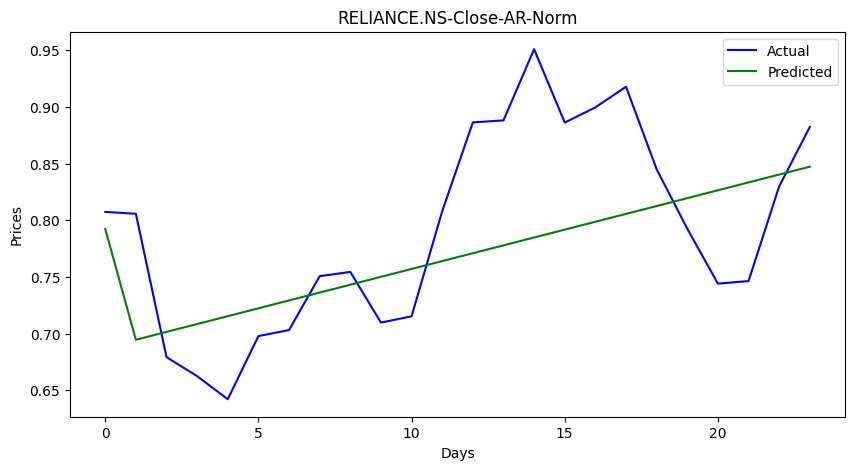

In [12]:
# Visualise model output
graph(Y_test, Y_pred, "Actual", "Predicted", "RELIANCE.NS-Close-AR-Norm", "Days", "Prices")

In [13]:
# Checking length of output
len(Data1)

122

In [14]:
# Check the test sample
Y_test

array([[0.80735718],
       [0.8057136 ],
       [0.67918128],
       [0.66236858],
       [0.64201743],
       [0.69776321],
       [0.70307155],
       [0.75060148],
       [0.75439326],
       [0.7096445 ],
       [0.71520685],
       [0.80798948],
       [0.88636093],
       [0.88813083],
       [0.95095553],
       [0.88623528],
       [0.89963383],
       [0.91783678],
       [0.84502633],
       [0.79256838],
       [0.74402786],
       [0.74630374],
       [0.82985788],
       [0.88231651]])

In [15]:
# Actual value calculation
TrueValue_A = conversionSingle(Y_test, [Column])
Stockprice_Value = MMS.inverse_transform(TrueValue_A)
Actual_Stockprice_Value = conversionSingle(Stockprice_Value, [Column])

In [16]:
# Predicted value calculation
TrueValue_P = conversionSingle(Y_pred, [Column])
Stockprice_Value = MMS.inverse_transform(TrueValue_P)
Predicted_Stockprice_Value = conversionSingle(Stockprice_Value, [Column])

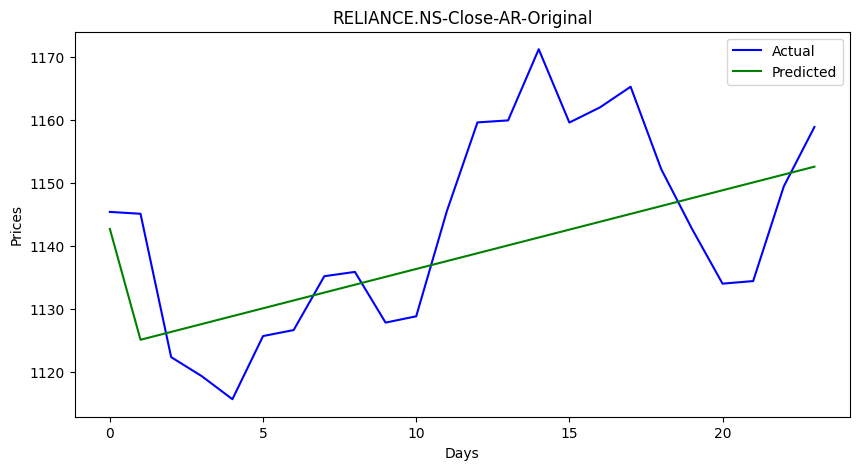

In [17]:
# Visualisation after calculation of actual and predicted values
graph(Actual_Stockprice_Value, Predicted_Stockprice_Value, "Actual", "Predicted", "RELIANCE.NS-Close-AR-Original", "Days", "Prices")

In [18]:
# Determine the RMS and MAP values for actual and predicted
rmsemape (Actual_Stockprice_Value, Predicted_Stockprice_Value)

RMSE-Testset: 13.2209929977108
maPe-Testset: 0.00941917623455231


In [19]:
# Farcasting for subsequent three days
Forecast = Model_fit.predict(len(Data1), len(Data1)+3)
Forecast 

array([0.85422243, 0.86116733, 0.86811222, 0.87505712])

In [20]:
# Carryout forecasting 
FTest_NormalTable = conversionSingle(Forecast , ["Closeforce"])
Stockprice_Original = MMS.inverse_transform(FTest_NormalTable)
Stockprice_Forecast = conversionSingle(Stockprice_Original, ["Closeforce"])
Stockprice_Forecast

,Closeforce
0,1153.773111
1,1155.02136
2,1156.269609
3,1157.517858


In [21]:
# Saving the final forecasted values
Stockprice_Forecast.to_csv("CloseMA_Forecast.csv", index = False)